# RDKit and pandas

[pandas](https://pandas.pydata.org/) is the standard Python library for working with tables of data. RDKit can put molecules directly into pandas tables, which makes it easy to calculate properties and search large sets of molecules.

This notebook introduces the basics of pandas as we go, so you don't need to have used it before. By the end you should be able to:

- create a table of molecules and add calculated properties to it
- recognise how salts and protonation affect calculated properties
- load a data file and select the rows and columns you want
- plot, sort and summarise a column
- run a substructure search on a whole table
- save your results

Cells marked **Exercise** are for you to try. A hidden solution follows each one - click "Solution" to show it, but have a go first!

## Setup

**Using Google Colab?** Run the cell below first: click it, then press **Shift + Enter** (or click the ▶ button on its left). It installs RDKit and downloads the data this notebook needs, and takes about 30 seconds. On your own computer it does nothing.

In [ ]:
# Setup for Google Colab (does nothing on your own computer)
import os, sys, urllib.request

if 'google.colab' in sys.modules:
    %pip install -q rdkit
    DATA_URL = 'https://raw.githubusercontent.com/dylancjohn/rdkit-tutorials/master/data/'
    os.makedirs('../data', exist_ok=True)
    for name in ['chembl_drugs.txt.gz']:
        if not os.path.exists('../data/' + name):
            urllib.request.urlretrieve(DATA_URL + name, '../data/' + name)

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import IPythonConsole

# draw molecules as pictures in every table
PandasTools.RenderImagesInAllDataFrames(images=True)

It's standard to import pandas as `pd`, so you'll see `pd.` in front of pandas functions.

# 1. A first table

The main object in pandas is the **DataFrame**: a table with named columns and numbered rows, a bit like a spreadsheet. One way to make one is from a dictionary, where each key is a column name and each value is a list containing that column's contents:

In [2]:
small = pd.DataFrame({
    'name': ['aspirin', 'paracetamol', 'ibuprofen', 'caffeine', 'ethanol'],
    'smiles': ['CC(=O)Oc1ccccc1C(=O)O', 'CC(=O)Nc1ccc(O)cc1', 'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
               'Cn1cnc2c1c(=O)n(C)c(=O)n2C', 'CCO'],
})
small

,name,smiles
0,aspirin,CC(=O)Oc1ccccc1C(=O)O
1,paracetamol,CC(=O)Nc1ccc(O)cc1
2,ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O
3,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C
4,ethanol,CCO


The numbers on the left are the **index**, pandas' label for each row.

We get a single column using square brackets and the column name. A column on its own is called a **Series**:

In [3]:
small['name']

0        aspirin
1    paracetamol
2      ibuprofen
3       caffeine
4        ethanol
Name: name, dtype: str

`PandasTools.AddMoleculeColumnToFrame` reads a column of SMILES and adds a new column containing RDKit molecules. These are drawn directly in the table:

,name,smiles,mol
0,aspirin,CC(=O)Oc1ccccc1C(=O)O,
1,paracetamol,CC(=O)Nc1ccc(O)cc1,
2,ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,
3,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,
4,ethanol,CCO,

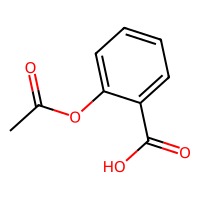
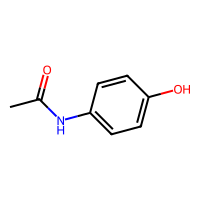
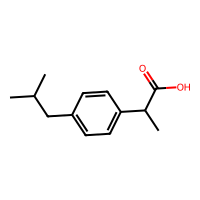
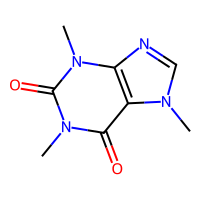
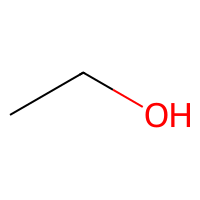

In [4]:
PandasTools.AddMoleculeColumnToFrame(small, smilesCol='smiles', molCol='mol')
small

Now we can calculate a property for every molecule. `.map()` runs a function on each value in a column, and we store the results in a new column by assigning to a new name:

,name,smiles,mol,MW
0,aspirin,CC(=O)Oc1ccccc1C(=O)O,,180.159
1,paracetamol,CC(=O)Nc1ccc(O)cc1,,151.165
2,ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,,206.285
3,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,,194.194
4,ethanol,CCO,,46.069

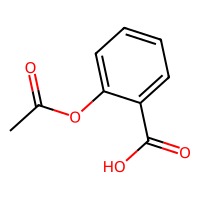
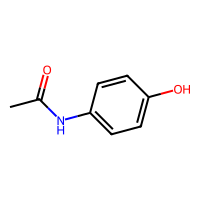
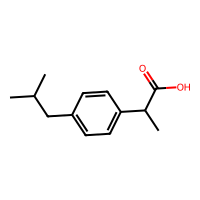
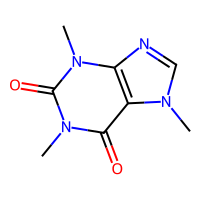
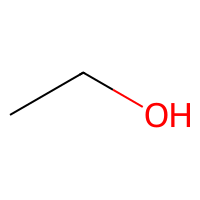

In [5]:
small['MW'] = small['mol'].map(Descriptors.MolWt)
small

`Descriptors` contains many other property calculators, for example `MolLogP` (lipophilicity), `NumHDonors`, `NumHAcceptors`, `TPSA` (polar surface area), `NumRotatableBonds` and `RingCount`.

To **filter** rows, we write a condition on a column. This gives a True/False value for each row:

In [6]:
small['MW'] > 190

0    False
1    False
2     True
3     True
4    False
Name: MW, dtype: bool

Putting that condition inside square brackets keeps only the rows where it is True. To select several columns, pass a list of column names, which is why there are double square brackets:

,name,smiles,mol,MW
2,ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,,206.285
3,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,,194.194

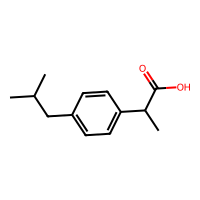
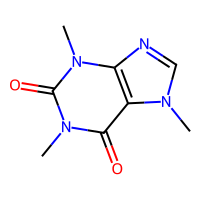

In [7]:
small[small['MW'] > 190]

In [8]:
small[['name', 'MW']]

,name,MW
0,aspirin,180.159
1,paracetamol,151.165
2,ibuprofen,206.285
3,caffeine,194.194
4,ethanol,46.069


### Exercise 1

1. Add a column called `logP` to `small` using `Descriptors.MolLogP`.
2. Show only the molecules with a logP greater than 1.

In [9]:
# Exercise 1: your code here

<details>
<summary>Solution</summary>

```python
small['logP'] = small['mol'].map(Descriptors.MolLogP)
small[small['logP'] > 1]
```

You should see aspirin, paracetamol and ibuprofen. Caffeine and ethanol have logP values below zero, meaning they prefer water to octanol.

</details>

# 2. Loading a real dataset

The `data` folder contains a table of drugs downloaded from [ChEMBL](https://www.ebi.ac.uk/chembl/). It is a tab-separated text file (compressed with gzip), which `pd.read_csv` can read directly:

In [10]:
df = pd.read_csv('../data/chembl_drugs.txt.gz', sep='\t')
df.shape

(11442, 29)

`shape` gives the number of (rows, columns). That's too big to look at all at once, so we list the column names and use `head()` to see the first 5 rows:

In [11]:
df.columns

Index(['PARENT_MOLREGNO', 'CHEMBL_ID', 'SYNONYMS', 'DEVELOPMENT_PHASE',
       'RESEARCH_CODES', 'APPLICANTS', 'USAN_STEM', 'USAN_STEM_DEFINITION',
       'USAN_STEM_SUBSTEM', 'USAN_YEAR', 'FIRST_APPROVAL', 'ATC_CODE',
       'ATC_CODE_DESCRIPTION', 'INDICATION_CLASS', 'SC_PATENT_NO', 'DRUG_TYPE',
       'RULE_OF_FIVE', 'FIRST_IN_CLASS', 'CHIRALITY', 'PRODRUG', 'ORAL',
       'PARENTERAL', 'TOPICAL', 'BLACK_BOX', 'AVAILABILITY_TYPE',
       'WITHDRAWN_YEAR', 'WITHDRAWN_COUNTRY', 'WITHDRAWN_REASON',
       'CANONICAL_SMILES'],
      dtype='str')

In [12]:
df[['CHEMBL_ID', 'SYNONYMS', 'DEVELOPMENT_PHASE', 'RULE_OF_FIVE', 'CANONICAL_SMILES']].head()

,CHEMBL_ID,SYNONYMS,DEVELOPMENT_PHASE,RULE_OF_FIVE,CANONICAL_SMILES
0,CHEMBL1201064,"Fluorometholone Acetate (FDA, USAN)",4,Y,C[C@H]1C[C@H]2[C@@H]3CC[C@](OC(=O)C)(C(=O)C)[C...
1,CHEMBL1009,"Levodopa (BAN, FDA, INN, JAN, USAN, USP)",4,Y,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O
2,CHEMBL1569487,"Lornoxicam (BAN, INN, USAN)",3,Y,CN1C(=C(O)c2sc(Cl)cc2S1(=O)=O)C(=O)Nc3ccccn3
3,CHEMBL270190,"Alvimopan (BAN, FDA, INN, USAN)",4,Y,C[C@H]1CN(C[C@H](Cc2ccccc2)C(=O)NCC(=O)O)CC[C@...
4,CHEMBL9,"Norfloxacin (BAN, FDA, INN, JAN, USAN, USP)",4,Y,CCN1C=C(C(=O)O)C(=O)c2cc(F)c(cc12)N3CCNCC3


`value_counts()` counts how often each value appears in a column. `DEVELOPMENT_PHASE` is the clinical trial phase, where 4 means the drug has been approved:

In [13]:
df['DEVELOPMENT_PHASE'].value_counts()

DEVELOPMENT_PHASE
0    6656
4    2260
2     971
3     902
1     653
Name: count, dtype: int64

# 3. Filtering the table

We'll keep only drugs that:

- have a SMILES string (some entries, such as antibodies, don't)
- pass Lipinski's "rule of five", a rule of thumb for drug-like small molecules: MW under 500, logP under 5, at most 5 H-bond donors and at most 10 H-bond acceptors
- are approved (phase 4)

To combine conditions, use `&` for AND and `|` for OR. Each condition must be in brackets:

In [14]:
has_smiles = df['CANONICAL_SMILES'].notnull()
passes_ro5 = df['RULE_OF_FIVE'] == 'Y'
approved = df['DEVELOPMENT_PHASE'] == 4

drugs = df[has_smiles & passes_ro5 & approved].copy()
len(drugs)

1284

Using `.copy()` makes `drugs` a separate table, so changing it later won't affect (or warn about) the original `df`.

### Exercise 2

The `FIRST_APPROVAL` column gives the year each drug was first approved. How many of our drugs were approved before 1950? Show their `SYNONYMS` and `FIRST_APPROVAL`.

In [15]:
# Exercise 2: your code here

<details>
<summary>Solution</summary>

```python
old = drugs[drugs['FIRST_APPROVAL'] < 1950]
print(len(old))   # 37
old[['SYNONYMS', 'FIRST_APPROVAL']]
```

</details>

# 4. Adding molecules and names

As before, we add a molecule column. We don't give it a name this time, so RDKit uses the default name `ROMol`:

In [16]:
PandasTools.AddMoleculeColumnToFrame(drugs, smilesCol='CANONICAL_SMILES')

# .notnull() removes any rows where RDKit couldn't read the SMILES
drugs = drugs[drugs['ROMol'].notnull()]
len(drugs)

1284

## Making short drug names

We'd like to label our drawings with each drug's name. The names are in the `SYNONYMS` column, so let's look at a few:

In [17]:
drugs['SYNONYMS'].head()

0            Fluorometholone Acetate (FDA, USAN)
1       Levodopa (BAN, FDA, INN, JAN, USAN, USP)
3                Alvimopan (BAN, FDA, INN, USAN)
4    Norfloxacin (BAN, FDA, INN, JAN, USAN, USP)
5            Oxcarbazepine (BAN, FDA, INN, USAN)
Name: SYNONYMS, dtype: str

Each entry has the drug's name followed by a list, in brackets, of the organisations that use that name (for example BAN = British Approved Name, FDA = the US Food and Drug Administration). Many drugs also have several alternative names separated by `;`. That's far too long for a label, so we'll keep just the first name: the text before the first `(`.

Let's work out how to do that on one piece of text first, using ordinary Python string methods:

In [18]:
text = 'Levodopa (BAN, FDA, INN, JAN, USAN, USP)'

pieces = text.split('(')   # split the text at each '(' into a list of pieces
print(pieces)

first = pieces[0]          # keep the first piece: 'Levodopa ' (with a space at the end)
print(first.strip())       # .strip() removes spaces from the start and end

['Levodopa ', 'BAN, FDA, INN, JAN, USAN, USP)']
Levodopa


pandas can do the same thing to every row at once. For a column of text, string methods go after `.str`:

- `.str.split('(')` splits every entry into pieces
- `.str[0]` keeps the first piece of each
- `.str.strip()` removes the spaces

We store the result in a new `name` column and compare it with the original:

In [19]:
drugs['name'] = drugs['SYNONYMS'].str.split('(').str[0].str.strip()

drugs[['SYNONYMS', 'name']].head()

,SYNONYMS,name
0,"Fluorometholone Acetate (FDA, USAN)",Fluorometholone Acetate
1,"Levodopa (BAN, FDA, INN, JAN, USAN, USP)",Levodopa
3,"Alvimopan (BAN, FDA, INN, USAN)",Alvimopan
4,"Norfloxacin (BAN, FDA, INN, JAN, USAN, USP)",Norfloxacin
5,"Oxcarbazepine (BAN, FDA, INN, USAN)",Oxcarbazepine


## Missing values

One drug has nothing in its `SYNONYMS` column. pandas marks missing values as `NaN` ("not a number"), and `.isnull()` finds them, just like `.notnull()` in section 3 but the other way round:

In [20]:
drugs[drugs['name'].isnull()][['CHEMBL_ID', 'SYNONYMS', 'name']]

,CHEMBL_ID,SYNONYMS,name
355,CHEMBL3707449,NaN,NaN


`.fillna()` replaces missing values with something else. We'll use the drug's ChEMBL ID as its name:

,name,ROMol
0,Fluorometholone Acetate,
1,Levodopa,
3,Alvimopan,
4,Norfloxacin,
5,Oxcarbazepine,

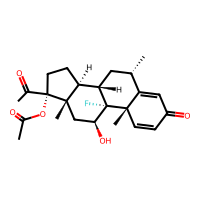
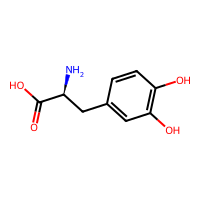
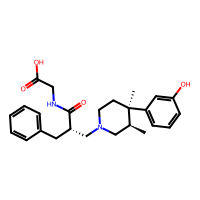
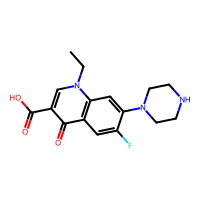
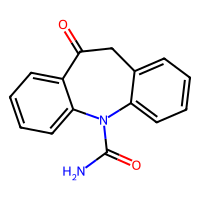

In [21]:
drugs['name'] = drugs['name'].fillna(drugs['CHEMBL_ID'])

drugs[['name', 'ROMol']].head()

`PandasTools.FrameToGridImage` draws the molecules from a table in a grid. `drugs.head(8)` gives the first 8 rows, and `legendsCol='name'` says which column to use for the labels:

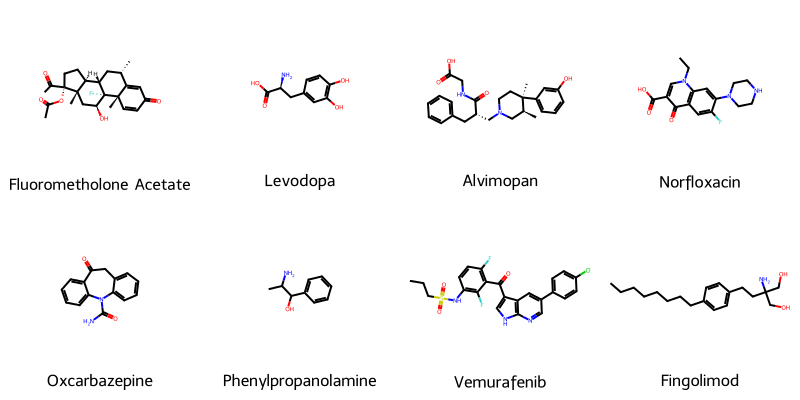

In [22]:
PandasTools.FrameToGridImage(drugs.head(8), legendsCol='name', molsPerRow=4)

# 5. Calculating and exploring properties

**Descriptors** are numbers calculated from a molecule's structure that describe things like its size or polarity. We'll calculate the four used in Lipinski's rule of five:

- `MolWt` - molecular weight
- `MolLogP` - an estimate of logP, which measures whether a molecule prefers an oily solvent (octanol) or water. Higher means more oily ("lipophilic"), negative means it prefers water.
- `NumHDonors` - number of hydrogen bond donors (roughly, NH and OH groups)
- `NumHAcceptors` - number of hydrogen bond acceptors (mostly N and O atoms)

As in section 1, `.map()` runs the function on every molecule in the column:

In [23]:
drugs['MW'] = drugs['ROMol'].map(Descriptors.MolWt)
drugs['logP'] = drugs['ROMol'].map(Descriptors.MolLogP)
drugs['HBD'] = drugs['ROMol'].map(Descriptors.NumHDonors)
drugs['HBA'] = drugs['ROMol'].map(Descriptors.NumHAcceptors)

drugs[['name', 'MW', 'logP', 'HBD', 'HBA']].head()

,name,MW,logP,HBD,HBA
0,Fluorometholone Acetate,418.505,3.4941,1,5
1,Levodopa,197.190,0.0522,4,4
3,Alvimopan,424.541,3.0514,3,4
4,Norfloxacin,319.336,1.2683,2,4
5,Oxcarbazepine,252.273,2.6422,1,2


## Before comparing properties: salts and molecular forms

A dataset may describe a molecule as a neutral compound, a protonated compound or a salt. The input form matters because RDKit calculates properties from the **whole structure we give it**.

Consider ethylamine and ethylamine hydrochloride. In the salt SMILES, `[NH3+]` is the protonated nitrogen, `[Cl-]` is chloride, and the dot separates disconnected fragments. The salt includes the counterion and an extra proton, so its total molecular weight differs from the neutral amine. We will inspect these two forms in a separate small table:

In [24]:
forms = pd.DataFrame({
    'form': ['ethylamine', 'ethylamine hydrochloride'],
    'smiles': ['CCN', 'CC[NH3+].[Cl-]']
})
PandasTools.AddMoleculeColumnToFrame(forms, smilesCol='smiles', molCol='mol')

Writing canonical SMILES changes how each structure is written; it does not turn the two forms into the same structure. The MW below is the molecular weight of each complete input record.

In [25]:
forms['canonical_smiles'] = forms['mol'].map(Chem.MolToSmiles)
forms['MW'] = forms['mol'].map(Descriptors.MolWt)
forms[['form', 'canonical_smiles', 'MW']]

,form,canonical_smiles,MW
0,ethylamine,CCN,45.085
1,ethylamine hydrochloride,CC[NH3+].[Cl-],81.546


Protonation can also change hydrogen-bonding properties. The neutral amine nitrogen has a lone pair that can accept a hydrogen bond; the protonated nitrogen is not an acceptor in this descriptor calculation.

### Exercise 3

Predict which form has an H-bond acceptor. Add an `HBA` column to `forms` using `Descriptors.NumHAcceptors`, then display the form, MW and HBA columns.

In [26]:
# Exercise 3: your code here

<details>
<summary>Solution</summary>

```python
forms['HBA'] = forms['mol'].map(Descriptors.NumHAcceptors)
forms[['form', 'MW', 'HBA']]
```

Ethylamine has 1 acceptor; its hydrochloride salt has 0. Their molecular weights are approximately 45.08 and 81.55 g/mol.
</details>

**Molecular preparation** means deciding which chemical form to compare. A project might preserve complete salts, choose a parent molecule, or use a defined protonation state. The choice should match the scientific question and be applied consistently. Removing a chloride fragment alone would still leave a protonated amine.

Canonicalisation helps compare equivalent ways of writing a structure. **Standardisation** applies a chosen policy to its chemical form; these are different operations. Tautomers can also remain distinct canonical structures. In this course we preserve the supplied forms unless a step explicitly says otherwise. Notebook 5 will apply canonicalisation to duplicate records and explain its limits.

## Summarising a column

A column has methods that summarise it in a single number, such as `.mean()`, `.min()` and `.max()`:

In [27]:
print('Average MW:', drugs['MW'].mean())
print('Smallest MW:', drugs['MW'].min())
print('Largest MW:', drugs['MW'].max())

Average MW: 298.3065436137072
Smallest MW: 17.031
Largest MW: 499.6190000000002


`describe()` calculates several of these at once, for each column:

- `count` - how many values there are
- `mean` and `std` - the average and standard deviation (how spread out the values are)
- `min` and `max` - the smallest and largest values
- `25%`, `50%`, `75%` - the quartiles. For example, a quarter of the drugs have values below `25%`. The `50%` value is the median.

In [28]:
drugs[['MW', 'logP', 'HBD', 'HBA']].describe()

,MW,logP,HBD,HBA
count,1284.000000,1284.000000,1284.000000,1284.000000
mean,298.306544,2.171239,1.602025,3.838785
std,98.076909,1.733162,1.255893,1.867728
min,17.031000,-3.380600,0.000000,0.000000
25%,232.004000,1.061225,1.000000,2.000000
50%,299.781500,2.365700,1.000000,4.000000
75%,371.312750,3.515220,2.000000,5.000000
max,499.619000,5.969400,5.000000,10.000000


No drug has more than 5 H-bond donors, 10 acceptors or a MW above 500, as expected since we kept only drugs that pass the rule of five.

## Plotting

pandas can plot a column directly. A **histogram** splits the values into ranges ("bins") and counts how many drugs fall into each one. `bins=30` sets the number of bars.

The plotting function gives back the plot (we call it `ax`), which we can use to add axis labels. The `;` at the end of the last line stops Jupyter printing some extra text above the plot.

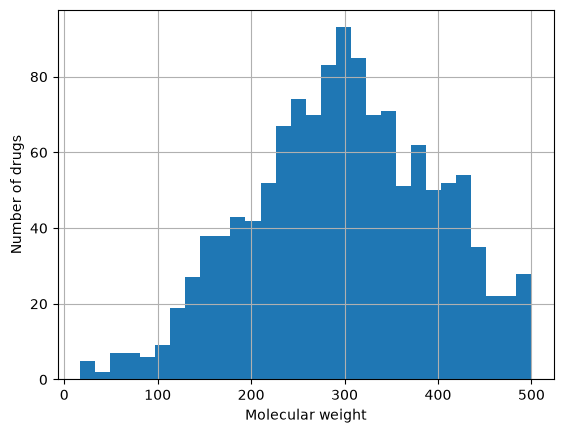

In [29]:
ax = drugs['MW'].hist(bins=30)
ax.set_xlabel('Molecular weight')
ax.set_ylabel('Number of drugs');

Most drugs have a MW between about 200 and 400, and there are none above 500 because of the rule-of-five filter.

A **scatter plot** compares two columns. Each point is one drug. `alpha=0.3` makes the points see-through, so you can see where lots of them overlap:

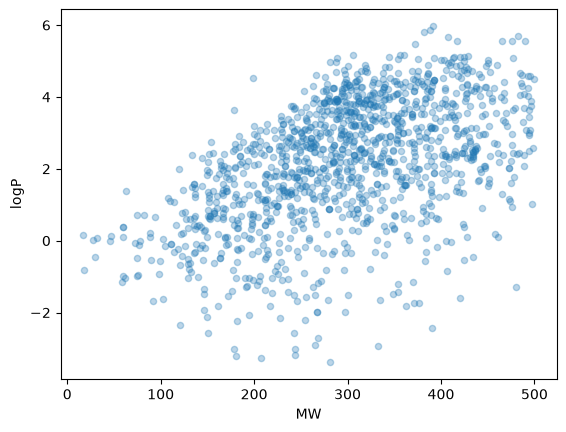

In [30]:
drugs.plot.scatter(x='MW', y='logP', alpha=0.3);

Larger molecules tend to have a higher logP, but there's a lot of spread: a large molecule with many polar groups can still prefer water.

## Sorting

`sort_values` sorts the table by a column. Use `ascending=False` to put the largest values first. The line below does three things, reading left to right: sort by logP, keep three columns, and show the first 5 rows.

In [31]:
drugs.sort_values('logP', ascending=False)[['name', 'MW', 'logP']].head()

,name,MW,logP
5237,Abiraterone Acetate,391.555,5.9694
161,Tioconazole,387.719,5.8629
34,Econazole,381.690,5.8014
378,Regorafenib,482.821,5.6888
163,Miltefosine,407.576,5.6755


Notice the numbers on the left: each row keeps its original index when the table is sorted or filtered.

### Exercise 4

1. Make a histogram of logP with labelled axes.
2. Draw the 6 **smallest** drugs by molecular weight. Any surprises?
3. The table was filtered to drugs that pass the rule of five, so how many have an RDKit logP above 5?

In [32]:
# Exercise 4: your code here

<details>
<summary>Solution</summary>

```python
ax = drugs['logP'].hist(bins=30)
ax.set_xlabel('logP')
ax.set_ylabel('Number of drugs');
```

```python
smallest = drugs.sort_values('MW').head(6)
PandasTools.FrameToGridImage(smallest, legendsCol='name')
```

They are ammonia, water, nitrogen, nitric oxide, oxygen and ethanol, all listed as approved medicines!

```python
len(drugs[drugs['logP'] > 5])   # 28
```

logP is a calculated estimate, and different programs give different values. ChEMBL's rule-of-five flag uses a different logP calculation from RDKit's, so a few drugs are just over 5 here.

</details>

# 6. Substructure searching a table

PandasTools lets us run a substructure search on a whole molecule column using `>=`, which you can read as "contains". The result is True/False for each row, so it can be used as a filter just like before.

Here we search for the core of the sulfonamide ("sulfa") drugs, an aniline with a sulfonyl group on the opposite side of the ring:

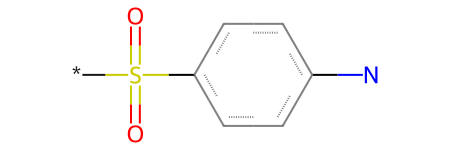

In [33]:
sulfa = Chem.MolFromSmarts('N-c1ccc(-S(=O)(=O)-[*])cc1')
sulfa

In [34]:
sulfa_drugs = drugs[drugs['ROMol'] >= sulfa]
len(sulfa_drugs)

35

The matching part is highlighted in the table:

,name,ROMol
45,Sulfadimethoxine,
48,Bendrofluazide,
51,Hydrochlorothiazide,
155,Sulfapyridine,
266,Sulfaphenazole,

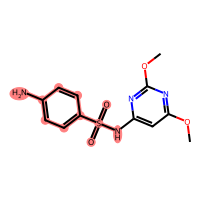
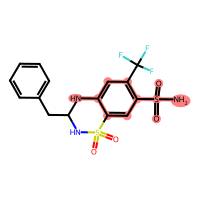
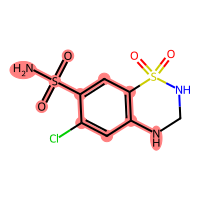
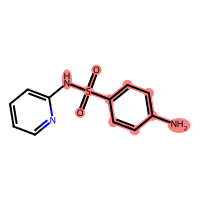
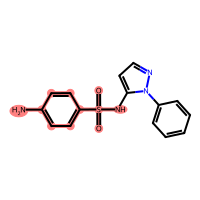

In [35]:
sulfa_drugs[['name', 'ROMol']].head()

For a grid image, we pass the matching atoms with `highlightAtomLists`, as in notebook 2:

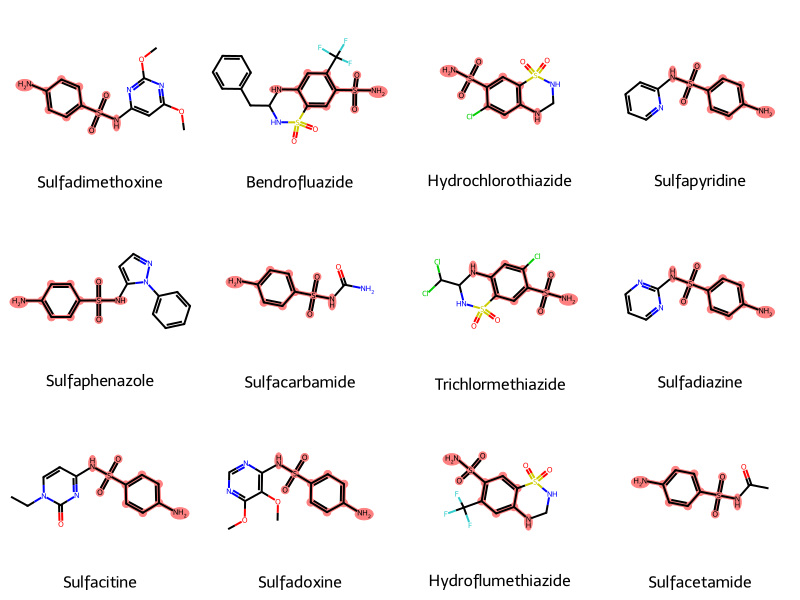

In [36]:
first12 = sulfa_drugs.head(12)

PandasTools.FrameToGridImage(first12, legendsCol='name', molsPerRow=4,
                             highlightAtomLists=[mol.GetSubstructMatch(sulfa) for mol in first12['ROMol']])

As well as sulfa antibiotics (sulfadiazine, sulfapyridine...), the pattern also finds thiazide diuretics such as hydrochlorothiazide, which contain the same arrangement of atoms inside a ring.

We can also save the search result as a new True/False column. Using the carboxylic acid pattern from notebook 2:

In [37]:
acid = Chem.MolFromSmarts('[CX3](=O)[OX2H1]')
drugs['has_acid'] = drugs['ROMol'] >= acid

drugs['has_acid'].value_counts()

has_acid
False    1060
True      224
Name: count, dtype: int64

`groupby` splits the table into groups by the values in one column, then summarises another column for each group. Here's the average logP of drugs with and without a carboxylic acid:

In [38]:
drugs.groupby('has_acid')['logP'].mean()

has_acid
False    2.236885
True     1.860592
Name: logP, dtype: float64

Drugs with an acid group have a lower average logP, i.e. they are more polar, which makes chemical sense.

### Exercise 5

Do the same for halogens (`[F,Cl,Br,I]`): add a `has_halogen` column, count how many drugs contain a halogen, and compare the average logP with and without one.

In [39]:
# Exercise 5: your code here

<details>
<summary>Solution</summary>

```python
halogen = Chem.MolFromSmarts('[F,Cl,Br,I]')
drugs['has_halogen'] = drugs['ROMol'] >= halogen

print(drugs['has_halogen'].value_counts())      # 338 True
drugs.groupby('has_halogen')['logP'].mean()     # about 1.9 without, 2.8 with
```

Halogenated drugs are more lipophilic on average.

</details>

### Exercise 6 (stretch)

The `INDICATION_CLASS` column says what each drug is used for. What are the three most common indication classes among the drugs that contain a carboxylic acid?

In [40]:
# Exercise 6: your code here

<details>
<summary>Solution</summary>

```python
acid_drugs = drugs[drugs['has_acid']]
acid_drugs['INDICATION_CLASS'].value_counts().head(3)
```

Antibacterial, anti-inflammatory and antihypertensive. Many antibiotics (e.g. penicillins) and anti-inflammatories (e.g. ibuprofen) contain a carboxylic acid.

</details>

# 7. Saving results

To save a table as a CSV file (which you can open in Excel), choose the columns you want and use `to_csv`. `index=False` leaves out the row numbers. The molecule column can't be saved in a CSV, but the SMILES column can:

In [41]:
columns = ['CHEMBL_ID', 'name', 'CANONICAL_SMILES', 'MW', 'logP', 'has_acid']
drugs[columns].to_csv('drug_properties.csv', index=False)

To keep the molecules, save as an SD file instead. The `approved_drugs.sdf` file used in notebook 2 was made like this. Here we save just the sulfa drugs to a new file:

In [42]:
PandasTools.WriteSDF(sulfa_drugs, 'sulfa_drugs.sdf', idName='CHEMBL_ID', properties=['name', 'MW', 'logP'])

You can read an SD file back into a table with `PandasTools.LoadSDF`:

,name,MW,logP,ID,ROMol
0,Sulfadimethoxine,310.335,0.8768,CHEMBL62193,
1,Bendrofluazide,421.422,1.6254,CHEMBL1684,
2,Hydrochlorothiazide,297.745,-0.3513,CHEMBL435,
3,Sulfapyridine,249.295,1.4646,CHEMBL700,
4,Sulfaphenazole,314.37,2.2553,CHEMBL1109,

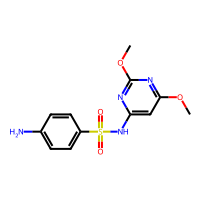
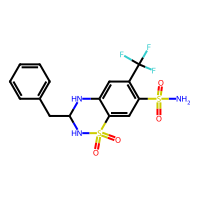
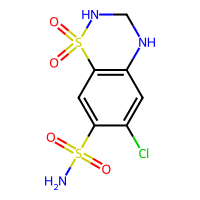
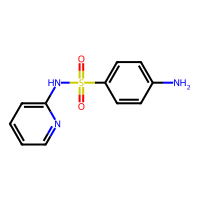
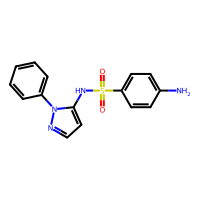

In [43]:
PandasTools.LoadSDF('sulfa_drugs.sdf').head()

Tutorial originally by Samo Turk, Jan. 2017. Expanded for this workshop.